Process data extracted from IFRC reports


In [3]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
from functions import *

In [4]:
file_path = '../Data_backup/all_ifrc_reports_info_unnested_processed_v3.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    all_ifrc_reports_info_unnested = json.load(json_file)

In [5]:
# filter for correct appeal type
filtered_reports = [
    disaster_report for disaster_report in all_ifrc_reports_info_unnested
    if disaster_report['appealType'] in ['Operations Update', 'DREF Operation', 'DREF Operation Final Report', 'DREF Operation Update']
]


In [6]:
# correct for hazard type
dict_hazards_grouped = {'Drought' : ['Drought', 'Dry Spell'],
                        'Flood' : ['Flood'],
                        'Cyclone' : ['Cyclone', 'Hurricane', 'Typhoon'],
                        'Storm' : ['Storm', 'Tornado'],
                        'Fire' : ['Fire', 'Wildfire'],
                        'Coldwave' : ['Coldwave'],
                        'Mass movement' : ['Mass movement'],
                        'Tsunami' : ['Tsunami']
                       }
nat_hazard_classes = ['Flood', 'Earthquake', 'Cyclone', 'Drought', 'Storm', 'Fire', 'Hurricane',
                    'Coldwave', 'Wildfire', 'Fire', 'Mass movement',
                      'Tsunami', 'Typhoon', 'Tornado']#'Volcanic Eruption' #Earthquake'
filtered_reports = change_hazard(filtered_reports,dict_hazards_grouped)

In [7]:
list_disasters = []

for element in all_ifrc_reports_info_unnested:
    if (element['pdfDownloaded'] == 1):
        list_disasters.append(element['disasterTypeReclassified'])

In [8]:
for item in filtered_reports:
    if 'text' in item:
        item['text_processed'] = clean_text(item['text'])


Tokenize reports into sentences

In [9]:
import nltk
nltk.download('punkt')  # Download the sentence tokenizer

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
# Iterate over each dictionary in the list
for item in filtered_reports:
    # Tokenize the 'text' into sentence
    if 'text_processed' in item:
        sentences = sent_tokenize(item['text_processed'])
        # Append tokenized sentences back into the dictionary
        item['sentences'] = sentences

In [11]:
#reclassify hazards in the correct categories
hazard_patterns = {
        'Drought': r"drought.*|dry spell.*",
        'Flood': r"\b(flood|floods|flooding|inundation|inundations|glacial lake outburst)\b",
        'Storm': r"storm.*|superstorm.*|tornado.*|windstorm.*|snowstorm.*|snowfal.*|blizzard.*|derecho.*|winterstorm.*|hail.*|extra tropical storm.*|thunderstorm.*",
        #'Tornado': r"tornado.*",
        #'Hurricane': r"hurricane.*",
        'Storm surge': r"storm surge.*",
        'Heatwave': r"heat wave.*|heatwave.*|heat episode.*|((heat|hot) spell).*|heat stress.*",
        'Coldwave': r"cold wave.*|coldwave.*|severe winter conditions.*|cold spell.*",
        'Mass movement': r"land slide.*|landslide.*|rockfall.*|mudslide.*|mass movement.*",
        #'Earthquake': r"earthquake.*",
        'Cyclone': r"cyclone.*|tropical cyclone.*|hurricane.*|typhoon.*",
        #'Volcano': r"volcan.*",
        'Tidal Wave': r"tidal wav.*",
        'Wildfire': r"fire.*|forestfire.*|wildfire.*|landfire.*|bushfire.*|forest fire.*|wild fire.*|land fire.*|bush fire.*"
    }


In [12]:
for disaster_report in filtered_reports:
    if 'sentences' in disaster_report:
        sentences = disaster_report['sentences']
        hazard_list_all_sentences = []
        disaster_report['sentencesHazards'] = []
        for sentence in sentences:
            hazard_list = check_hazard_type_keyword(sentence, hazard_patterns)
            if hazard_list != 'None':
                if len(hazard_list) > 1:
                    disaster_report['sentencesHazards'].append(sentence)
                    hazard_list_all_sentences.append(hazard_list)
        disaster_report['hazard_list'] = hazard_list_all_sentences

In [13]:
#count single and multi-hazards
ifrc_reports_natural_hazards = []
count_multi = 0
count_single = 0
for element in filtered_reports:
    haz_set_unique = set()
    if  'hazard_list' in element:
        haz_set_unique = {tuple(hazlist) for hazlist in element['hazard_list']}
    element['haz_set_unique'] = haz_set_unique
    #element['haz_list_unique'] = np.unique(np.array(np.array(element['hazard_list'])).flatten())
    element['haz_list_unique'] = list(set([item for sublist in element['hazard_list'] for item in sublist]))


In [14]:
element['haz_set_unique']

{('Flood', 'Mass movement')}

In [15]:
element['hazard_list']

[['Flood', 'Mass movement']]

Identifying single events and compounding events

In [16]:
ifrc_reports_natural_hazards = []
count_multi = 0
count_single = 0
for element in filtered_reports:
    if  ('haz_list_unique' in element):
        if len(element['haz_set_unique']) > 1:
            element['multiHazard'] = 1
            count_multi += 1
        else:
            element['multiHazard'] = 0
            count_single += 1


In [17]:
element['haz_set_unique']

{('Flood', 'Mass movement')}

In [18]:
count_multi

147

In [19]:
7/147

0.047619047619047616

In [20]:
count_single+count_multi

679

In [21]:
for element in filtered_reports[3:25]:
    print(element['disasterType'])
    print(element['sentencesHazards'])
    print(element['hazard_list'])
    print('---')

Cyclone
['The storm surge, accompanied by extremely heavy rainfall, caused flooding of 58 feet in the coastal districts.', 'The water sources and sanitation facilities in the affected districts were heavily damaged by the cyclone Remal, due to inundation caused by storm surges.', 'On the other hand, the latrines in the houses of affected communities have been damaged by heavy storm winds and prolonged flooding caused by tidal surges and heavy rainfall.']
[['Flood', 'Storm', 'Storm surge'], ['Flood', 'Storm', 'Storm surge', 'Cyclone'], ['Flood', 'Storm']]
---
Flood
[]
[]
---
Drought
['In May 2024, the Heads of State from the Southern African Development Community SADC held an Extraordinary Summit to address the cumulative challenges posed by El Nioinduced droughts and floods, specifically focusing on Botswana.']
[['Drought', 'Flood']]
---
Storm Surge
['DREF OPERATION Gabon Windstorm House destroyed by the windstorm surge, 15 May 2023 Appeal MDRGA010 Country Gabon Hazard Storm Surge Type

# Extract event name and date

In [22]:
nlp = spacy.load("en_core_web_sm")
report_sample = filtered_reports[:]

In [23]:
'oods' in report_sample[20]['sentencesHazards']

False

In [24]:
def extract_entities(text):
    # Process the text with spaCy
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

def extract_event_name_date(sentence):
    #entities = extract_entities(sentence)
    entities = extract_entities(sentence)
    dates = []
    places = []
    # Iterate over the tokens in the sentence
    for ent_set in entities:
        if ent_set[1] == 'DATE':
            dates.append(ent_set[0])

        if ent_set[1] == 'LOC':
            places.append(ent_set[0])


    return dates, places


In [25]:
#first need to extract entities
for report in report_sample:
    report['compound_dict'] = {}
    if len(report['sentencesHazards'])>0:
        #report['entities'] = extract_entities(report['sentencesHazards'])
        for i, sent_haz in enumerate(report['sentencesHazards']):
            haz_list = report['hazard_list'][i]
            multi_haz_name = ", ".join(haz_list)
            report['compound_dict'][multi_haz_name] = {}
            dates, places = extract_event_name_date(sent_haz)
            #report['compound_dict'][multi_haz_name]['hazards'] = haz_list
            report['compound_dict'][multi_haz_name]['dates'] = dates
            report['compound_dict'][multi_haz_name]['places'] = places



In [26]:
report_sample[20]['compound_dict']

{'Storm, Mass movement': {'dates': ['2022', '16 November 2022', 'this year'],
  'places': []},
 'Storm, Cyclone': {'dates': [], 'places': ['Caribbean']}}

In [27]:
irep = 20
rep = report_sample[irep]
print(rep["reportName"]+": "+rep['reportLink'])
for i,sent in enumerate(rep['sentencesHazards']):
    haz_list = rep['hazard_list'][i]
    haz_list_str = ", ".join(haz_list)
    print(sent)
    print('-'*100)
    print(haz_list_str+": ")
    print(rep['compound_dict'][haz_list_str])
    print('-'*100)
    print('-'*100)

Colombia - Floods (MDRCO022): https://adore.ifrc.org/Download.aspx?FileId=793548
In the consolidated report of the 2022 rainy season, issued on 16 November 2022 by the National Unit for Disaster Risk Management, UNGRD, it has been noted that so far this year, 806 oods have been recorded, 1,180 mass movements, 299 ash oods, 219 gales, 100 torrential oods, 32 hailstorms, 83 storms and 8 thunderstorms, causing communities in a state of vulnerability to face ooding in their homes or total losses, damage to sewage networks, aqueducts, road infrastructure, health centers, educational institutions, and livelihoods, mainly agricultural activities.
----------------------------------------------------------------------------------------------------
Storm, Mass movement: 
{'dates': ['2022', '16 November 2022', 'this year'], 'places': []}
----------------------------------------------------------------------------------------------------
------------------------------------------------------------

# Causal relationships

In [28]:
# Load the SpaCy English model
nlp = spacy.load("en_core_web_sm")

In [29]:
# Define a list of causal verbs
causal_verbs = ['cause', 'trigger', 'lead', 'result', 'bring', 'induce', 'exacerbate', 'contribute', 'prompt',
                'create', 'generate', 'produce', 'promote', 'force', 'drive', 'influence', 'encourage', 'stimulate', 'initiate']

temporal_verbs = ['precede', 'succeed', 'follow', 'antedate', 'postdate', 'supersede', 'anticipate', 'overlap', 'coincide', 'preempt', 'intervene', 'occur', 'transpire', 'emerge', 'arise']

In [30]:
def extract_causal_relationships(sentence, relationship_list ,hazard_patterns):
    doc = nlp(sentence)
    causes = []

    # Iterate over the tokens in the sentence
    for token in doc:
        # Check if the token is a verb and in the list of causal verbs
        if token.lemma_ in relationship_list and token.pos_ == 'VERB':
            # Find the subject (nsubj) and object (dobj) of the verb
            subject = None
            effect = None

            for child in token.children:
                if child.dep_ == 'nsubj' and len(check_hazard_type_keyword(child.text, hazard_patterns)) > 0:  # Subject (the cause)
                    subject = child.text #check_hazard_type_keyword(child.text, hazard_patterns)
                if child.dep_ in ['dobj', 'pobj'] and len(check_hazard_type_keyword(child.text, hazard_patterns)) > 0:  # Object (the effect)
                    effect = child.text #check_hazard_type_keyword(child.text, hazard_patterns)
            # If both subject and object (effect) are found, return the relationship
            if subject and effect:
                causes.append((subject, token.lemma_, effect))

    return causes


In [31]:
# Apply the function to extract causal relationships
causal = 0
for disaster_report in filtered_reports[:]:
    if 'sentencesHazards' in disaster_report:
        sentences = disaster_report['sentencesHazards']
        for sentence in sentences:
            causal_relations = extract_causal_relationships(sentence, causal_verbs ,hazard_patterns)
            if causal_relations:
                causal+=1
                for cause in causal_relations:
                    #if (len(check_hazard_type_keyword(cause[0], hazard_patterns))>0) and (len(check_hazard_type_keyword(cause[2],hazard_patterns))>0):
                    print(f"Sentence: {sentence}")
                    print(f"  Causal relationship: {cause[0]} -> {cause[2]} (via '{cause[1]}')")
                    print("----")

Sentence: Still suffering from Super Typhoon Goni, Bicol was the first to face Typhoon Vamcos winds and rain, as the typhoon triggered floods in parts of the region.
  Causal relationship: typhoon -> floods (via 'trigger')
----
Sentence: Meanwhile, on 8 April 2013, severe rainstorms caused further flooding and the destruction of property and farmlands in Agona East district in the Central region.
  Causal relationship: rainstorms -> flooding (via 'cause')
----
Sentence: Summary The announced intensive rain and snow storms that started on January 7th and are still striking large parts of the OPT have generated floods in several parts of the country.
  Causal relationship: storms -> floods (via 'generate')
----
Sentence: The hurricane caused flooding and landslides across Central Mexico as it passed over the Sierra Madre Oriental range.
  Causal relationship: hurricane -> flooding (via 'cause')
----
Sentence: The hurricane caused flooding and landslides across Central Mexico as it passed

In [32]:
causal

7

## Plots

In [33]:
list_compound_hazards = []
list_compound_hazards_non_unique = []

for item in filtered_reports:
    if item['multiHazard'] == 1:
        list_compound_hazards.append(item['haz_list_unique'])
        list_compound_hazards_non_unique.append(item['haz_set_unique'])


In [34]:
item['haz_set_unique']

{('Flood', 'Mass movement')}

In [37]:
list_compound_hazards_non_unique

[{('Flood', 'Mass movement'), ('Flood', 'Storm')},
 {('Flood', 'Mass movement'),
  ('Flood', 'Storm'),
  ('Flood', 'Storm', 'Storm surge'),
  ('Flood', 'Wildfire')},
 {('Flood', 'Storm'),
  ('Flood', 'Storm', 'Storm surge'),
  ('Flood', 'Storm', 'Storm surge', 'Cyclone')},
 {('Flood', 'Mass movement'), ('Mass movement', 'Cyclone')},
 {('Flood', 'Cyclone'), ('Flood', 'Mass movement')},
 {('Flood', 'Mass movement'),
  ('Storm', 'Coldwave'),
  ('Storm', 'Coldwave', 'Mass movement')},
 {('Flood', 'Mass movement'), ('Flood', 'Wildfire'), ('Storm', 'Cyclone')},
 {('Storm', 'Cyclone'), ('Storm', 'Mass movement')},
 {('Flood', 'Mass movement', 'Cyclone'), ('Storm', 'Cyclone')},
 {('Flood', 'Mass movement', 'Cyclone'), ('Storm', 'Cyclone')},
 {('Drought', 'Coldwave'), ('Storm', 'Coldwave')},
 {('Flood', 'Cyclone'),
  ('Flood', 'Mass movement', 'Cyclone'),
  ('Storm', 'Cyclone')},
 {('Flood', 'Mass movement'), ('Flood', 'Mass movement', 'Cyclone')},
 {('Flood', 'Mass movement'), ('Flood', 'Storm

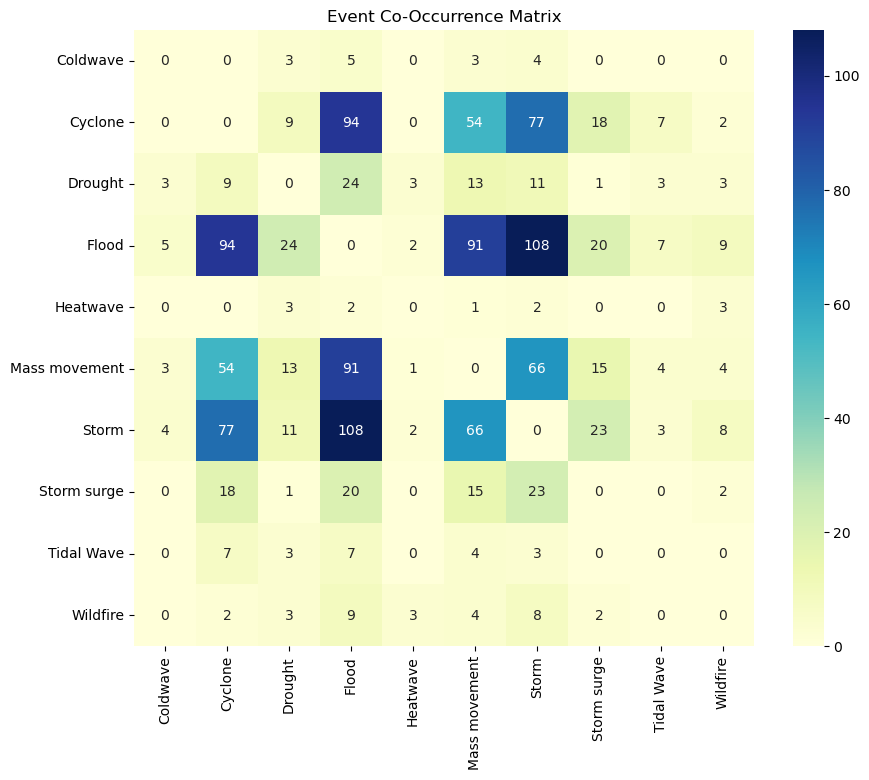

In [36]:
# Step 1: Identify unique events
unique_events = set()
for event_list in list_compound_hazards:
    unique_events.update(event_list)
unique_events = sorted(unique_events)

# Step 2: Create the co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=unique_events, columns=unique_events)

for event_list in list_compound_hazards:
    for i in range(len(event_list)):
        for j in range(i, len(event_list)):
            if i != j:
                co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1
                co_occurrence_matrix.loc[event_list[j], event_list[i]] += 1

# Step 3: Plot the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Event Co-Occurrence Matrix")
plt.show()